# Regression with the General Social Survey

This notebook explores how income relates to education, age and sex using an extract from the General Social Survey (GSS), then finishes with a logistic regression predicting support for gun permits.

The GSS is a long-running sociological survey of US residents, maintained by NORC at the University of Chicago. The full dataset has hundreds of columns and can be found at https://gss.norc.org/get-the-data. Here we work with a small extract holding just the columns we need.

Every code cell keeps the original comments so you can follow what each line does. Run the cells in order.

## Imports and plot style

We load pandas for the data, seaborn and matplotlib for charts, numpy and scipy for the maths, and statsmodels for the regressions. Then we set a clean seaborn style.

In [ ]:
import pandas as pd          # THE data analysis library - like Excel but much more powerful
import seaborn as sns        # Makes beautiful statistical plots easily
import matplotlib.pyplot as plt  # The basic plotting library (seaborn uses this underneath)
import numpy as np           # Math operations and working with arrays of numbers
from scipy import stats     # Advanced statistical functions
import statsmodels.formula.api as smf  # For regression modeling
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Set up how we want our plots to look (like choosing a theme)
sns.set_style("ticks")      # This gives a clean look with borders

## Load the data

Read the GSS extract from CSV and peek at the first few rows to check it loaded correctly.

In [21]:
# Load our data from a CSV file
gss = pd.read_csv('https://raw.githubusercontent.com/kostis-christodoulou/am01-code-sep2026/main/data/gss_extract_2022.csv')
gss.head()

,Unnamed: 0,year,id,age,educ,degree,sex,gunlaw,grass,realinc
0,0,1972,1,23.0,16.0,3.0,2.0,1.0,NaN,18951.0
1,1,1972,2,70.0,10.0,0.0,1.0,1.0,NaN,24366.0
2,2,1972,3,48.0,12.0,1.0,2.0,1.0,NaN,24366.0
3,3,1972,4,27.0,17.0,3.0,2.0,1.0,NaN,30458.0
4,4,1972,5,61.0,12.0,1.0,2.0,1.0,NaN,50763.0


## A first regression: income and education

We start simple, estimating real income as a function of years of education. First we keep only the rows where both variables are present, then fit the model. `summary2()` prints the results without scientific notation, and we report the residual standard error alongside.

In [22]:
# We'll start with a simple regression, estimating the parameters of real income as a function of years of education.
# First we'll select the subset of the data where both variables are valid.
regression_df = gss[['realinc', 'educ']].dropna()


model1 = smf.ols('realinc ~ educ', data=gss).fit()
print(model1.summary2()) # summary2 avoids scientific notation
print(f"Residual SE: {model1.scale ** 0.5:.3f}")  # Residual standard error is the square root of the scale (MSE of residuals)

                   Results: Ordinary least squares
Model:               OLS              Adj. R-squared:     0.138       
Dependent Variable:  realinc          AIC:                1514270.2938
Date:                2026-09-06 17:35 BIC:                1514288.4522
No. Observations:    64808            Log-Likelihood:     -7.5713e+05 
Df Model:            1                F-statistic:        1.039e+04   
Df Residuals:        64806            Prob (F-statistic): 0.00        
R-squared:           0.138            Scale:              8.2227e+08  
----------------------------------------------------------------------
             Coef.    Std.Err.    t     P>|t|     [0.025      0.975]  
----------------------------------------------------------------------
Intercept -15007.4536 480.0747 -31.2607 0.0000 -15948.4003 -14066.5070
educ        3631.0761  35.6253 101.9241 0.0000   3561.2505   3700.9017
----------------------------------------------------------------------
Omnibus:             22858

## Income and age on its own

Now the same idea with age as the single predictor.

In [23]:
# Compute the regression of `realinc` as a function of `age`
model2 = smf.ols('realinc ~ age', data=gss).fit()
print(model2.summary2()) 
print(f"Residual SE: {model2.scale ** 0.5:.3f}")  # Residual standard error is the square root of the scale (MSE of residuals)

                   Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.000       
Dependent Variable: realinc          AIC:                1516854.6011
Date:               2026-09-06 17:35 BIC:                1516872.7506
No. Observations:   64521            Log-Likelihood:     -7.5843e+05 
Df Model:           1                F-statistic:        25.84       
Df Residuals:       64519            Prob (F-statistic): 3.73e-07    
R-squared:          0.000            Scale:              9.4961e+08  
---------------------------------------------------------------------
               Coef.    Std.Err.    t    P>|t|    [0.025     0.975]  
---------------------------------------------------------------------
Intercept    34148.7942 346.1253 98.6602 0.0000 33470.3883 34827.2001
age            -35.7775   7.0388 -5.0829 0.0000   -49.5736   -21.9814
---------------------------------------------------------------------
Omnibus:              24976.481      Du

## Education and age together

In model3 `realinc` is the variable we are trying to explain or predict, which is called the **dependent variable** because it depends on the the other
variables -- or at least we expect it to.
The other variables, `educ` and `age`, are called **independent variables** or sometimes "predictors".
The `+` sign indicates that we expect the contributions of the independent variables to be additive.
The result contains an intercept and two slopes, which estimate the average contribution of each predictor with the other predictor held constant.
* The estimated slope for `educ` is about 3665 -- so if we compare two people with the same age, and one has an additional year of education,
 we expect their income to be higher by $3665.
* The estimated slope for `age` is about 55 -- so if we compare two people with the same education, and one is a year older, we expect their income to be higher by $55.

In this model, the contribution of age is quite small, but as we'll see in the next section that might be misleading.

In [24]:
model3 = smf.ols('realinc ~ educ + age', data=gss).fit()
print(model3.summary2())
print(f"Residual SE: {model3.scale ** 0.5:.3f}")  # Residual standard error is the square root of the scale (MSE of residuals)

                   Results: Ordinary least squares
Model:               OLS              Adj. R-squared:     0.139       
Dependent Variable:  realinc          AIC:                1504853.8376
Date:                2026-09-06 17:35 BIC:                1504881.0571
No. Observations:    64419            Log-Likelihood:     -7.5242e+05 
Df Model:            2                F-statistic:        5205.       
Df Residuals:        64416            Prob (F-statistic): 0.00        
R-squared:           0.139            Scale:              8.1809e+08  
----------------------------------------------------------------------
             Coef.    Std.Err.    t     P>|t|     [0.025      0.975]  
----------------------------------------------------------------------
Intercept -17999.7269 604.5874 -29.7719 0.0000 -19184.7187 -16814.7352
educ        3665.1082  35.9744 101.8810 0.0000   3594.5984   3735.6181
age           55.0718   6.6003   8.3438 0.0000     42.1351     68.0085
--------------------------

## Why is age's effect so small?

To understand that small age slope, we group income by age and look at the average for each age. We also print the full per-age describe() so you can see the spread.

In [25]:
grouped = gss.groupby('age')
type(grouped)
mean_income_by_age = grouped['realinc'].mean().reset_index()

gss.groupby('age')['realinc'].mean()
gss.groupby('age')['realinc'].describe()

,count,mean,std,min,25%,50%,75%,max
age,,,,,,,,
18.0,195.0,34972.926756,35948.477708,218.0,10475.06250,24543.0000,42462.0000,144835.428600
19.0,720.0,30303.052561,31340.572646,218.0,8270.43750,20355.0000,39022.5000,162607.000000
20.0,788.0,24120.840617,25357.927422,218.0,7384.00000,16284.0000,32761.0000,162607.000000
21.0,961.0,23400.413828,27499.610085,218.0,6503.75000,14015.0000,29430.0000,162607.000000
22.0,1038.0,23178.205343,25927.101725,218.0,7269.28125,15075.0000,28785.0000,155139.973100
...,...,...,...,...,...,...,...,...
85.0,162.0,19332.231786,22119.125660,1071.0,7767.46875,12398.0000,21190.0000,144502.717140
86.0,173.0,17708.729744,21477.941580,218.0,5116.50000,10850.0000,21318.7500,144835.428600
87.0,102.0,14467.830392,14591.972894,245.0,5347.18750,10380.8125,17401.3125,99956.000000


### Average income by age

A scatter of the mean income at each age.

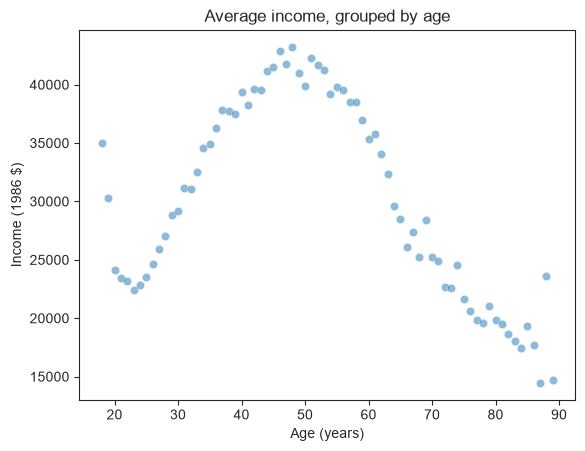

In [26]:
# Seaborn scatter plot
sns.scatterplot(data=mean_income_by_age,
                x='age', 
                y='realinc', 
                alpha=0.5)
plt.xlabel('Age (years)')
plt.ylabel('Income (1986 $)')
plt.title('Average income, grouped by age')
plt.show()

### Average income by age and sex

The same view, now split by sex with a custom blue and orange palette.

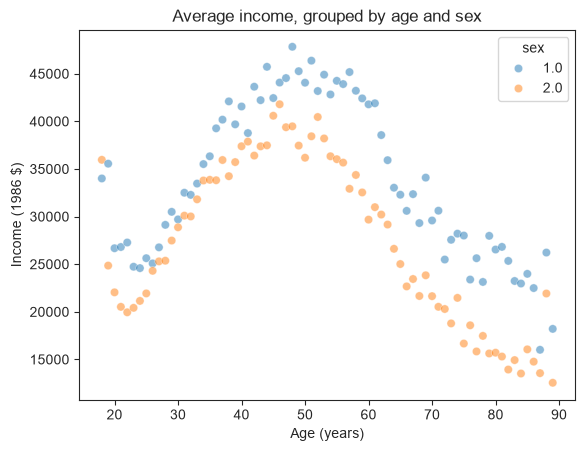

In [27]:
# Group by both 'age' and 'sex' in pandas
grouped = gss.groupby(['age', 'sex'])
mean_income = grouped['realinc'].mean().reset_index()

# Seaborn scatter plot

# Define a palette where the first color is blue, the second is orange
custom_palette = ["#1f77b4", "#ff7f0e"]

sns.scatterplot(data=mean_income,
                x='age', 
                y='realinc', 
                hue='sex',
                palette=custom_palette,
                alpha=0.5)
plt.xlabel('Age (years)')
plt.ylabel('Income (1986 $)')
plt.title('Average income, grouped by age and sex')
plt.show()

## A non-linear relationship: adding age squared

Average income increases from age 20 to age 50, then starts to fall.
And that explains why the estimated slope is so small, because the relationship is non-linear.
To describe a non-linear relationship, we'll create a new variable called `age2` that equals `age` squared -- so it is called a **quadratic term**.

In [28]:
gss['age2'] = gss['age'] ** 2

# Now we can estimate a model that includes the quadratic term.
model4 = smf.ols('realinc ~ educ + age + age2', data=gss).fit()
print(model4.summary2())
print(f"Residual SE: {model4.scale ** 0.5:.3f}")  # Residual standard error is the square root of the scale (MSE of residuals)

                   Results: Ordinary least squares
Model:               OLS              Adj. R-squared:     0.168       
Dependent Variable:  realinc          AIC:                1502617.8657
Date:                2026-09-06 17:35 BIC:                1502654.1584
No. Observations:    64419            Log-Likelihood:     -7.5130e+05 
Df Model:            3                F-statistic:        4351.       
Df Residuals:        64415            Prob (F-statistic): 0.00        
R-squared:           0.169            Scale:              7.9017e+08  
----------------------------------------------------------------------
             Coef.    Std.Err.    t     P>|t|     [0.025      0.975]  
----------------------------------------------------------------------
Intercept -52599.6748 937.4297 -56.1105 0.0000 -54437.0378 -50762.3119
educ        3464.8707  35.6033  97.3187 0.0000   3395.0881   3534.6532
age         1779.1964  36.7080  48.4689 0.0000   1707.2486   1851.1441
age2         -17.4453   0.

## Exercise: is education non-linear too?

**Exercise:** The graph in the previous exercise suggests that the relationship between income and education is non-linear.  So let's try fitting a non-linear model.

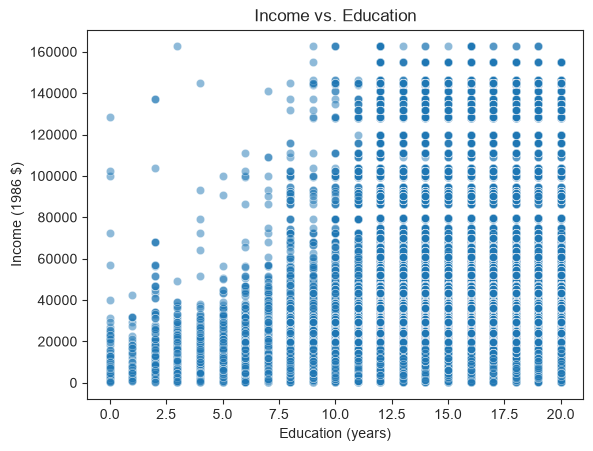

In [29]:
# - Add a column named `educ2` to the `gss` DataFrame -- it should contain the values from `educ` squared.  
gss['educ2'] = gss['educ'] ** 2

# - Make a scatter plot of `realinc` vs. `educ` (like we did for `age`), and see if the relationship looks non-linear.
sns.scatterplot(data=gss, x='educ', y='realinc', alpha=0.5)
plt.xlabel('Education (years)')
plt.ylabel('Income (1986 $)')
plt.title('Income vs. Education')
plt.show()

### Regression with the squared terms

Add `educ2` and fit a model that uses education, education squared, age and age squared together.

In [30]:
# - Add a column named `educ2` to the `gss` DataFrame -- it should contain the values from `educ` squared.  
gss['educ2'] = gss['educ'] ** 2
# - Run a regression that uses `educ`, `educ2`, `age`, and `age2` to predict `realinc`.
model6 = smf.ols('realinc ~ educ + educ2 + age + age2', data=gss).fit()
print(model6.summary2())
print(f"Residual SE: {model6.scale ** 0.5:.3f}")  # Residual standard error is the square root of the scale (MSE of residuals)

                    Results: Ordinary least squares
Model:                OLS              Adj. R-squared:     0.177       
Dependent Variable:   realinc          AIC:                1501990.8742
Date:                 2026-09-06 17:35 BIC:                1502036.2401
No. Observations:     64419            Log-Likelihood:     -7.5099e+05 
Df Model:             4                F-statistic:        3454.       
Df Residuals:         64414            Prob (F-statistic): 0.00        
R-squared:            0.177            Scale:              7.8250e+08  
-----------------------------------------------------------------------
             Coef.     Std.Err.    t     P>|t|     [0.025      0.975]  
-----------------------------------------------------------------------
Intercept -26336.7663 1400.5608 -18.8044 0.0000 -29081.8666 -23591.6661
educ        -706.0741  169.6492  -4.1620 0.0000  -1038.5866   -373.5616
educ2        165.9626    6.6015  25.1401 0.0000    153.0236    178.9015
age         

## Adding sex as a predictor

`C(sex)` tells statsmodels to treat sex as a categorical variable rather than a number.

In [31]:
# What if we add 'sex' as a predictor?
model5 = smf.ols('realinc ~ educ + age + age2 + C(sex)', data=gss).fit() # C() tells statsmodels to treat 'sex' as a categorical variable
print(model5.summary2())
print(f"Residual SE: {model5.scale ** 0.5:.3f}")  # Residual standard error is the square root of the scale (MSE of residuals)

                     Results: Ordinary least squares
Model:                 OLS               Adj. R-squared:      0.176       
Dependent Variable:    realinc           AIC:                 1501858.5236
Date:                  2026-09-06 17:35  BIC:                 1501903.8887
No. Observations:      64410             Log-Likelihood:      -7.5092e+05 
Df Model:              4                 F-statistic:         3431.       
Df Residuals:          64405             Prob (F-statistic):  0.00        
R-squared:             0.176             Scale:               7.8344e+08  
--------------------------------------------------------------------------
                 Coef.    Std.Err.    t     P>|t|     [0.025      0.975]  
--------------------------------------------------------------------------
Intercept     -49252.7648 944.2649 -52.1599 0.0000 -51103.5248 -47402.0048
C(sex)[T.2.0]  -5221.4172 221.7508 -23.5463 0.0000  -5656.0491  -4786.7854
educ            3445.1681  35.4640  97.1455 0.0

## A categorical outcome: support for gun permits

One of the GSS questions asks "Would you favor or oppose a law which would require a person to obtain a police permit before he or she could buy a gun?"
The responses are in a column called `gunlaw` -- here are the values.

In [32]:
gss['gunlaw'].value_counts() # counts
gss['gunlaw'].value_counts(normalize=True) # proportions

gunlaw
1.0    0.752831
2.0    0.247169
Name: proportion, dtype: float64

### Recoding the outcome to 0 and 1

`1` means yes and `2` means no, so most respondents are in favor.
Before we can use this variable in a logistic regression, we have to recode it so `1` means "yes" and `0` means "no".
We can do that by replacing `2` with `0`.

In [33]:
gss['gunlaw'] = gss['gunlaw'].replace({2: 0})

### Logistic regression

With a 0/1 outcome we switch to logistic regression to predict the category.

In [34]:
logit_model = smf.logit('gunlaw ~ educ + educ2 + age + age2 + C(sex)', data=gss).fit()
print(logit_model.summary2())

Optimization terminated successfully.
         Current function value: 0.544026
         Iterations 5
                          Results: Logit
Model:              Logit            Method:           MLE        
Dependent Variable: gunlaw           Pseudo R-squared: 0.026      
Date:               2026-09-06 17:35 AIC:              51799.9747 
No. Observations:   47597            BIC:              51852.5979 
Df Model:           5                Log-Likelihood:   -25894.    
Df Residuals:       47591            LL-Null:          -26572.    
Converged:          1.0000           LLR p-value:      3.3556e-291
No. Iterations:     5.0000           Scale:            1.0000     
-------------------------------------------------------------------
                Coef.   Std.Err.     z     P>|z|    [0.025   0.975]
-------------------------------------------------------------------
Intercept       1.4837    0.1358  10.9248  0.0000   1.2176   1.7499
C(sex)[T.2.0]   0.7407    0.0217  34.0917  0.0000

### Reading the coefficients and generating predictions

The coefficients are in log odds: positive values make the outcome more likely and negative values make it less likely. For example the coefficient on `sex=2` is about 0.74, which says women are more likely to support this form of gun control.

To evaluate the model we score the rows it was fit on and compare the predicted classes against the actual answers. `predict()` only returns the complete-case rows, so we rebuild that subset and keep the index aligned throughout.

In [35]:
# The logistic model was fit only on rows with no missing values in any of its
# variables, so logit_model.predict() returns results for those rows alone (fewer
# than len(gss)). We rebuild that same set of rows and keep everything aligned to
# their index, which is what the original version got wrong.
model_vars = ['gunlaw', 'educ', 'educ2', 'age', 'age2', 'sex']
fit_df = gss[model_vars].dropna()  # the complete cases the model was actually fit on

# predicted probability of gunlaw=1, as a Series indexed like fit_df
predicted_probs = logit_model.predict(fit_df)

# the actual 0/1 labels for those same rows
true_labels = fit_df['gunlaw'].astype(int)

# classify as 1 if predicted_prob >= 0.5, else 0
predicted_classes = (predicted_probs >= 0.5).astype(int)

# write predictions back onto the full gss frame; rows that were not scored get
# NaN, and because both sides share an index the alignment is automatic
gss['predicted_gunlaw'] = predicted_classes

# predicted_probs and true_labels are already complete and aligned, but we keep a
# mask so the evaluation below stays robust to any stray missing values
mask = predicted_probs.notna() & true_labels.notna()
clean_probs = predicted_probs[mask]
clean_true = true_labels[mask]

print(len(true_labels), len(predicted_classes)) # should be the same length

47597 47597


## Evaluating the classifier

We compare the predictions against the actual answers. The confusion matrix shows how many respondents were classified correctly at the 0.5 threshold, the accuracy and AUC summarise overall performance, and the ROC curve shows the trade-off between true and false positives across every threshold. An AUC of 0.5 is no better than chance and 1.0 is perfect.

Confusion matrix (threshold 0.5):
                    predicted: oppose (0)  predicted: favor (1)
actual: oppose (0)                      0                 11725
actual: favor (1)                       0                 35872

True negatives: 0   False positives: 11725
False negatives: 0   True positives: 35872

Accuracy: 0.754
AUC:      0.610


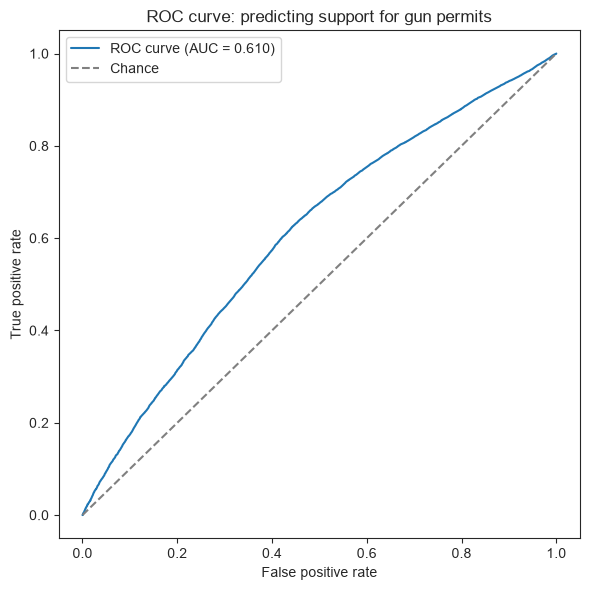

In [36]:
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

cm = confusion_matrix(clean_true, clean_probs >= 0.5)  # confusion matrix at threshold 0.5
tn, fp, fn, tp = cm.ravel()

auc_score = roc_auc_score(clean_true, clean_probs)

# ROC curve points:
fpr, tpr, thresholds = roc_curve(clean_true, clean_probs)

# --- show the confusion matrix with readable labels ---
cm_df = pd.DataFrame(cm,
                     index=['actual: oppose (0)', 'actual: favor (1)'],
                     columns=['predicted: oppose (0)', 'predicted: favor (1)'])
print('Confusion matrix (threshold 0.5):')
print(cm_df)
print(f'\nTrue negatives: {tn}   False positives: {fp}')
print(f'False negatives: {fn}   True positives: {tp}')

# --- headline numbers ---
accuracy = (tp + tn) / cm.sum()
print(f'\nAccuracy: {accuracy:.3f}')
print(f'AUC:      {auc_score:.3f}')

# --- plot the ROC curve ---
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve: predicting support for gun permits')
plt.legend()
plt.tight_layout()
plt.show()